In [4]:
pip install numpy pandas matplotlib seaborn

  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.2-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached pillow-11.2.1-cp313-cp313-win_amd64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached matplotlib-3.10.3-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.w

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path_to_files = '../out/build/vs-debug/media/csv/'

#### Sequential dataframes ####
seq_path = path_to_files + 'seq_w_cyl/'
columns = ['checkpoint', 'frame', 'dt', 'tot_sphs', 'frustum_sphs', 'vis_sphs', 'tot_cyls', 'frustum_cyls', 'vis_cyls', 'top_mipmap_level']
seq_ft = pd.read_csv(seq_path + 'loaded_scene_frame_times.csv', header=None, names=columns)
seq_occ_ft = pd.read_csv(seq_path + 'occ_loaded_scene_frame_times.csv', header=None, names=columns)

seq_ft.describe()

,checkpoint,frame,dt,tot_sphs,frustum_sphs,vis_sphs,tot_cyls,frustum_cyls,vis_cyls,top_mipmap_level
count,38516.000000,38516.000000,38516.000000,38516.000000,38516.000000,38516.000000,38516.000000,38516.000000,38516.000000,0.0
mean,56.903573,2325.738966,0.007333,86.311767,69.326098,69.326098,84.589469,69.888748,69.888748,NaN
std,34.894352,1526.392293,0.002594,58.529057,59.459441,59.459441,69.688252,67.822648,67.822648,NaN
min,0.000000,0.000000,0.002836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,44.000000,1069.000000,0.005558,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,51.000000,2139.000000,0.006544,126.000000,125.000000,125.000000,142.000000,36.000000,36.000000,NaN
75%,92.000000,3402.000000,0.008526,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,NaN
max,98.000000,6727.000000,0.026507,126.000000,126.000000,126.000000,142.000000,142.000000,142.000000,NaN


In [4]:
def mean_dts_between_tracks(df, name=''):
    """
    Calculate the mean dt in a track of checkpoints in a DataFrame.
    """

    df = df.copy()  # importante para evitar modificar el original
    df['fps'] = 1.0 / df['dt']
    df_range_0_10 = df[(df['checkpoint'] >= 0) & (df['checkpoint'] <= 10)]
    df_range_44_54 = df[(df['checkpoint'] >= 44) & (df['checkpoint'] <= 54)]
    df_range_88_98 = df[(df['checkpoint'] >= 88) & (df['checkpoint'] <= 98)]

    df_range_0_10_mean = df_range_0_10.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_range_44_54_mean = df_range_44_54.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()
    df_range_88_98_mean = df_range_88_98.groupby(['tot_sphs', 'tot_cyls'])['fps'].mean().reset_index()

    print(f"{name} FPS mean (checkpoint 0–10):")
    print(df_range_0_10_mean)
    print(f"{name} FPS mean (checkpoint 44–54):")
    print(df_range_44_54_mean)
    print(f"{name} FPS mean (checkpoint 88–98):")
    print(df_range_88_98_mean)

mean_dts_between_tracks(seq_ft, 'Sequential version without occlusion culling')
print("\n")
mean_dts_between_tracks(seq_occ_ft, 'Sequential version with occlusion culling')

Sequential version without occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls         fps
0         0       142   98.617593
1       126         0  135.992408
2       126       142   77.554391
Sequential version without occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls         fps
0         0       142  129.473933
1       126         0  164.128183
2       126       142  100.360160
Sequential version without occlusion culling FPS mean (checkpoint 88–98):
   tot_sphs  tot_cyls         fps
0         0       142  181.945873
1       126         0  214.018705
2       126       142  152.670835


Sequential version with occlusion culling FPS mean (checkpoint 0–10):
   tot_sphs  tot_cyls        fps
0         0       142  28.073293
1       126         0  29.456704
2       126       142  24.194606
Sequential version with occlusion culling FPS mean (checkpoint 44–54):
   tot_sphs  tot_cyls        fps
0         0       142  30.856337
1       126         0  32.5687

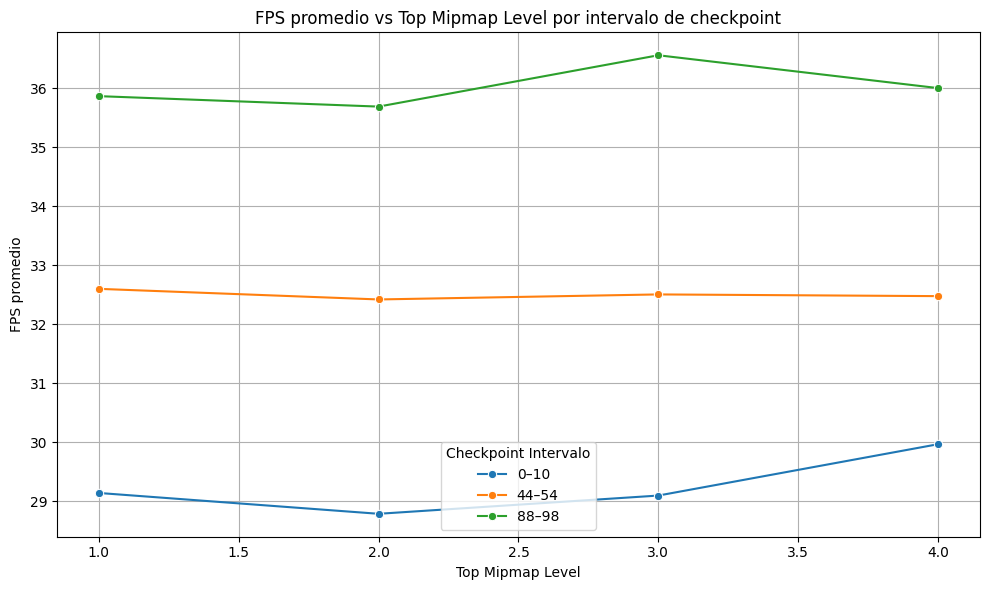

In [5]:
def plot_fps_vs_top_mipmap(df, tot_sphs=126, tot_cyls=0):
    # Asegurar columna FPS
    df = df[(df['tot_sphs'] == tot_sphs) & (df['tot_cyls'] == tot_cyls)].copy()
    df['fps'] = 1.0 / df['dt']

    # Filtrar por cada intervalo
    intervals = {
        '0–10': df[(df['checkpoint'] >= 0) & (df['checkpoint'] <= 10)],
        '44–54': df[(df['checkpoint'] >= 44) & (df['checkpoint'] <= 54)],
        '88–98': df[(df['checkpoint'] >= 88) & (df['checkpoint'] <= 98)]
    }

    # Preparar DataFrame combinado
    plot_data = []

    for label, df_range in intervals.items():
        grouped = df_range.groupby('top_mipmap_level')['fps'].mean().reset_index()
        grouped['interval'] = label
        plot_data.append(grouped)

    final_df = pd.concat(plot_data, ignore_index=True)

    # Graficar
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=final_df,
        x='top_mipmap_level',
        y='fps',
        hue='interval',
        marker='o'
    )

    plt.title('FPS promedio vs Top Mipmap Level por intervalo de checkpoint')
    plt.xlabel('Top Mipmap Level')
    plt.ylabel('FPS promedio')
    plt.legend(title='Checkpoint Intervalo')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_fps_vs_top_mipmap(seq_occ_ft)